## Waist partial mechanism Dynamics

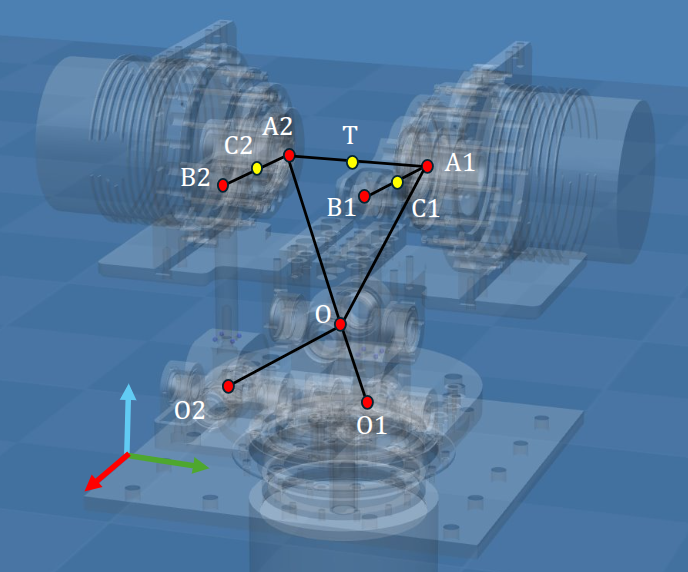

In [1]:
import sympy as sp
import numpy as np
import sympy.physics.mechanics as me 
me.init_vprinting()
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## Frames, Points, coordinates

In [2]:
N, B, U1, U2 = sp.symbols('N, B, U_1, U_2', cls=me.ReferenceFrame)
O, T, C1, C2 = sp.symbols('O, T, C_1, C_2', cls=me.Point)                                 # CoM points for the bodies
A1, A2, B1, B2, O1, O2 = sp.symbols('A_1, A_2, B_1, B_2, O_1, O_2', cls=me.Point)         # points for constraints / loop closure
q1, q2, q3, q4 = me.dynamicsymbols('q1:5', real="True")


ls, lc, lr, lf, lt1, lt2 = sp.symbols('l_s, l_c, l_r, l_f l_t1 l_t2' , positive="True", real="True")
m_t, m_c, g = sp.symbols('m_t, m_c, g', real="True", positive="True")
I_B_Bo = me.inertia(B, 1, 1, 1)
I_U1_U1o = me.inertia(U1, 1, 1, 1)
I_U2_U2o = me.inertia(U2, 1, 1, 1)
t = me.dynamicsymbols._t

T1, T2, T3 = me.dynamicsymbols('T1 T_joint18 T_joint19 ')


In [3]:
p = sp.Matrix([ls, lc, lr, lf, lt1, lt2, m_t, m_c, g])

u1, u2, u3, u4 = me.dynamicsymbols('u1:5')

q = sp.Matrix([q1, q2])
q_r = sp.Matrix([q3, q4])
q_N = q.col_join(q_r)

u = sp.Matrix([u1, u2])
u_r = sp.Matrix([u3, u4])
u_N = u.col_join(u_r)

udot = u.diff(t)
udot_N = u_N.diff(t)

qdot_N = q_N.diff(t)
qddot_N = qdot_N.diff(t)

q_zero = {q:0 for q in q}
q_N_zero = {q:0 for q in q_N}
qdot_N_zero = {qd: 0 for qd in qdot_N}

u_zero = {u: 0 for u in u}
u_r_zero = {u: 0 for u in u_r}
u_N_zero = {u: 0 for u in u_N}
udot_zero = {u:0 for u in udot}
udot_N_zero = {ud: 0 for ud in udot_N}

q, q_r, q_N, u, u_r, u_N, udot

⎛            ⎡q₁⎤              ⎡u₁⎤      ⎞
⎜            ⎢  ⎥              ⎢  ⎥      ⎟
⎜⎡q₁⎤  ⎡q₃⎤  ⎢q₂⎥  ⎡u₁⎤  ⎡u₃⎤  ⎢u₂⎥  ⎡u₁̇⎤⎟
⎜⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥⎟
⎜⎣q₂⎦  ⎣q₄⎦  ⎢q₃⎥  ⎣u₂⎦  ⎣u₄⎦  ⎢u₃⎥  ⎣u₂̇⎦⎟
⎜            ⎢  ⎥              ⎢  ⎥      ⎟
⎝            ⎣q₄⎦              ⎣u₄⎦      ⎠

## Framing and coordinates setting

In [4]:
B.orient_space_fixed(N, (q3, q4, 0),'XYZ')
U1.orient_axis(B, B.y, q1)

U2.orient_axis(B, B.y, q2)

O1.set_pos(O, lc*N.x + ls/2*N.y - lf*N.z)
O2.set_pos(O, lc*N.x - ls/2*N.y - lf*N.z)

T.set_pos(O, lt1*B.x + (lr - lf + lt2)*B.z)

A1.set_pos(T, -lt1*B.x + ls/2*B.y - lt2*B.z)
C1.set_pos(A1, lc/2*U1.x)
B1.set_pos(C1, lc/2*U1.x)

A2.set_pos(T, -lt1*B.x - ls/2*B.y - lt2*B.z)
C2.set_pos(A2, lc/2*U2.x)
B2.set_pos(C2, lc/2*U2.x)

In [5]:
# position check

B1.pos_from(O).express(N).xreplace(q_N_zero)

In [6]:
# loop closure equations

rod_constraint1 = B1.pos_from(O) - O1.pos_from(O)
rod_constraint2 = B2.pos_from(O) - O2.pos_from(O)


## Algebraic Holonomic constraint equations

In [7]:
# Holonomic constraints

fh = sp.Matrix([
    rod_constraint1.dot(rod_constraint1) - lr**2,
    rod_constraint2.dot(rod_constraint2) - lr**2,
    ])

fh = fh.applyfunc(lambda i: sp.simplify(sp.trigsimp(i)))

In [8]:
fh

⎡                                                                              ↪
⎢     2                                2                        2              ↪
⎢2⋅l_c ⋅sin(q₁)⋅sin(q₄)⋅cos(q₃) - 2⋅l_c ⋅cos(q₁)⋅cos(q₄) + 2⋅l_c  - 2⋅l_c⋅l_f⋅ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢     2                                2                        2              ↪
⎢2⋅l_c ⋅sin(q₂)⋅sin(q₄)⋅cos(q₃) - 2⋅l_c ⋅cos(q₂)⋅cos(q₄) + 2⋅l_c  - 2⋅l_c⋅l_f⋅ ↪
⎣                                                                              ↪

↪                                                                              ↪
↪                                                                              ↪
↪ sin(q₁)⋅cos(q₃)⋅cos(q₄) + 2⋅l_c⋅l_f⋅sin(q₁) - 2⋅l_c⋅l_f⋅sin(q₄)⋅cos(q₁) + 2⋅ ↪
↪                          

## Kinematic differential equations

In [9]:
fk = sp.Matrix([
    q1.diff(t) - u1,
    q2.diff(t) - u2,
    q3.diff(t) - u3,
    q4.diff(t) - u4,
])

Mk = fk.jacobian(qdot_N)
gk = fk.xreplace(qdot_N_zero)
qdot_N_sol = -Mk.LUsolve(gk)

qdot_N_replace = dict((zip(qdot_N, qdot_N_sol)))
qdot_N_replace

In [10]:
Mk, -gk, qdot_N

⎛⎡1  0  0  0⎤  ⎡u₁⎤  ⎡q₁̇⎤⎞
⎜⎢          ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎜⎢0  1  0  0⎥  ⎢u₂⎥  ⎢q₂̇⎥⎟
⎜⎢          ⎥, ⎢  ⎥, ⎢  ⎥⎟
⎜⎢0  0  1  0⎥  ⎢u₃⎥  ⎢q₃̇⎥⎟
⎜⎢          ⎥  ⎢  ⎥  ⎢  ⎥⎟
⎝⎣0  0  0  1⎦  ⎣u₄⎦  ⎣q₄̇⎦⎠

In [11]:
fh_d = fh.diff(t).xreplace(qdot_N_replace)

Mh_d = fh_d.jacobian(u_r)
gh_d = fh_d.xreplace(u_r_zero)

me.find_dynamicsymbols(fh.diff(t)), me.find_dynamicsymbols(fh_d), me.find_dynamicsymbols(gh_d)

In [12]:
u_r_sol = -Mh_d.LUsolve(gh_d)
# u_r_sol = sp.trigsimp(u_r_sol.simplify())

u_r_replace = dict(zip(u_r, u_r_sol))

me.find_dynamicsymbols(u_r_sol)

## Linear & Angular velocities

In [13]:
qdot_N_replace = dict((zip(qdot_N, qdot_N_sol)))
qddot_N_replace = dict(zip(qddot_N,udot_N))

w_B_N  = B.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
w_U1_N = U1.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)
w_U2_N = U2.ang_vel_in(N).xreplace(qdot_N_replace).xreplace(u_r_replace)

wd_B_N  = B.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
wd_U1_N = U1.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
wd_U2_N = U2.ang_acc_in(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)

In [14]:
me.find_dynamicsymbols(w_U2_N, reference_frame=N), me.find_dynamicsymbols(wd_U2_N, reference_frame=N)

## Linear & angular acceleration

In [15]:
me.find_dynamicsymbols(B.ang_acc_in(N), reference_frame=N)

In [16]:
O.set_vel(N,0)
v_T_N  = T.v2pt_theory(O, N, B).xreplace(qdot_N_replace).xreplace(u_r_replace)
v_C1_N = C1.v2pt_theory(O, N, U1).xreplace(qdot_N_replace).xreplace(u_r_replace)
v_C2_N = C2.v2pt_theory(O, N, U2).xreplace(qdot_N_replace).xreplace(u_r_replace)

a_T_N  = T.acc(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
a_C1_N = C1.acc(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)
a_C2_N = C2.acc(N).xreplace(qdot_N_replace).xreplace(qddot_N_replace).xreplace(u_r_replace)

In [17]:
me.find_dynamicsymbols(v_C2_N, reference_frame=N), me.find_dynamicsymbols(a_C2_N, reference_frame=N)

## Generalised Active and Inertial forces

In [18]:
# Forces

R_T  = -m_t*g*N.z
R_C1 = -m_c*g*N.z 
R_C2 = -m_c*g*N.z

# Torques

# T_B = -T2*B.y -T3*B.y
# T_U1 = T2*U1.y
# T_U2 = T3*U2.y

T_B = me.Vector(0)
T_U1 = me.Vector(0)
T_U2 = me.Vector(0)


In [19]:

ang_vel = [w_B_N, w_U1_N, w_U2_N]
lin_vel = [v_T_N, v_C1_N, v_C2_N]
 
ang_acc = [wd_B_N, wd_U1_N, wd_U2_N]
lin_acc = [a_T_N, a_C1_N, a_C2_N]

masses = [m_t, m_c, m_c]
forces = [R_T, R_C1, R_C2]

inertias = [I_B_Bo, I_U1_U1o, I_U2_U2o]
torques = [T_B, T_U1, T_U2]

Fr_bar = []
Frs_bar = []

for ur in [u1, u2]:

    Fr = 0
    Frs = 0

    for vi, ai, Ri, mi in zip(lin_vel, lin_acc, forces, masses):
        vr = vi.diff(ur, N)
        Fr += vr.dot(Ri)
        Rs = -mi*ai
        Frs += vr.dot(Rs)

    for wi, aai, Ti, Ii in zip(ang_vel, ang_acc, torques, inertias):
        wr = wi.diff(ur, N)
        Fr += wr.dot(Ti)
        Ts = -(aai.dot(Ii) +
               me.cross(wi, Ii).dot(wi))
        Frs += wr.dot(Ts)

    Fr_bar.append(Fr)
    Frs_bar.append(Frs)

Fr = sp.Matrix(Fr_bar)
Frs = sp.Matrix(Frs_bar)

In [20]:
me.find_dynamicsymbols(Fr), me.find_dynamicsymbols(Frs)

## Equations of Motion

In [21]:
EOM = Fr + Frs

## Static torque on the joints

In [22]:

parameters = {
    g: 9.81,
    lc: 0.075,
    lf: 0.025,
    lr: 0.115,
    ls: 0.08,
    lt1: 0.0, # upper body cg x (front)
    lt2: 0.35, # upper body cg z 
    m_c: 0.2,
    m_t: 25.0, # upper body mass
    q1: sp.rad(-10.22956697),
    q2: sp.rad(-10.22956697),
    q3: sp.rad(0.0),
    q4: sp.rad(10.0)
}

EOM_num = EOM.xreplace(parameters).xreplace(u_zero).xreplace(udot_zero).evalf(n=5).doit()

Ts = [T2, T3]

sp.Eq(sp.Matrix(Ts),-EOM_num)

⎡T_joint18⎤   ⎡8.9499⎤
⎢         ⎥ = ⎢      ⎥
⎣T_joint19⎦   ⎣8.9499⎦

## Simulation and visualization

In [23]:
Md = Frs.jacobian(udot)
gd = Frs.xreplace(udot_zero) + Fr

me.find_dynamicsymbols(Mk) , me.find_dynamicsymbols(gk), me.find_dynamicsymbols(Md) , me.find_dynamicsymbols(gd)

In [24]:

Mk = Mk.xreplace(u_r_replace)
gk = gk.xreplace(u_r_replace)

me.find_dynamicsymbols(Mk) , me.find_dynamicsymbols(gk), me.find_dynamicsymbols(Md) , me.find_dynamicsymbols(gd)

In [25]:

eval_k = sp.lambdify((q_N, u, p), (Mk, gk))


In [26]:

# eval_d = sp.lambdify((q_N, u, p), (Md, gd))

In [27]:

# def eval_rhs(t, x, p):
#     """Return the derivative of the state at time t.

#     Parameters
#     ==========
#     t : float
#     x : array_like, shape(4,)
#        x = [q1, q2, q3, u1]
#     p : array_like, shape(6,)
#        p = [la, lb, lc, ln, m, g]

#     Returns
#     =======
#     xd : ndarray, shape(4,)
#        xd = [q1d, q2d, q3d, u1d]

#     """

#     qN = x[:4]  # shape(3,)
#     u = x[4:]   # shape(1,)

#     Mk, gk = eval_k(qN, u, p)
#     qNd = -np.linalg.solve(Mk, np.squeeze(gk))

#     # Md, gd, and ud are each shape(1,1)
#     Md, gd = eval_d(qN, u, p)
#     ud = -np.linalg.solve(Md, gd)[0]

#     return np.hstack((qNd, ud))

In [28]:
# eval_fh = sp.lambdify((q_r, q, p), fh)

# i = sp.Matrix([q1, q2])
# o = sp.Matrix([q3, q4])

# p_vals = np.array([0.08, 0.075, 0.115, 0.025, 0.1, 0.35, 20.0, 0.15, 9.81])
# i_vals = np.deg2rad([0.0, 10.0])
# o_guess = np.deg2rad([0.0, 0.0]) 


# q3_, q4_ = fsolve(
#     lambda o, i, p: np.squeeze(eval_fh(o, i, p)),
#     o_guess,
#     args=(i_vals, p_vals),
#     xtol=1.49012e-10)
